In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/DATASET_TESIS_CIC/CLASIFICACIÓN/CB_DATASET_MULTICLASS-MULTILABEL.csv", encoding="utf-8")

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=10000)
X = vectorizer.fit_transform(df['text_cleaned']).toarray()

In [ ]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

le = LabelEncoder()
y = le.fit_transform(df['category_single'])
y_cat = to_categorical(y)  # Para clasificación multiclase

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y_cat, test_size=0.2, random_state=42, stratify=y_cat)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Dense(512, activation='relu', input_shape=(X.shape[1],)),
    Dropout(0.4),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(y_cat.shape[1], activation='softmax')  # o 'sigmoid' si multilabel
])

model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=5, batch_size=64)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
2086/2086 ━━━━━━━━━━━━━━━━━━━━ 46s 22ms/step - accuracy: 0.7612 - loss: 1.0261 - val_accuracy: 0.8521 - val_loss: 0.4932
Epoch 2/5
2086/2086 ━━━━━━━━━━━━━━━━━━━━ 42s 20ms/step - accuracy: 0.8854 - loss: 0.4154 - val_accuracy: 0.9240 - val_loss: 0.3047
Epoch 3/5
2086/2086 ━━━━━━━━━━━━━━━━━━━━ 43s 21ms/step - accuracy: 0.9388 - loss: 0.2449 - val_accuracy: 0.9409 - val_loss: 0.2470
Epoch 4/5
2086/2086 ━━━━━━━━━━━━━━━━━━━━ 43s 20ms/step - accuracy: 0.9581 - loss: 0.1706 - val_accuracy: 0.9484 - val_loss: 0.2201
Epoch 5/5
2086/2086 ━━━━━━━━━━━━━━━━━━━━ 43s 21ms/step - accuracy: 0.9672 - loss: 0.1304 - val_accuracy: 0.9550 - val_loss: 0.2035


In [ ]:
import numpy as np
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(y_true, y_pred_classes, target_names=le.classes_))

1043/1043 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
                   precision    recall  f1-score   support

     discapacidad       1.00      0.11      0.20       142
             edad       0.97      0.92      0.95      2008
          estatus       0.82      0.81      0.81       304
            etnia       0.95      0.83      0.88      1376
           género       0.90      0.77      0.83      2480
not_ciberbullying       0.96      0.99      0.98     25810
             odio       0.94      0.84      0.89      1251
         religión       0.00      0.00      0.00         3

         accuracy                           0.95     33374
        macro avg       0.82      0.66      0.69     33374
     weighted avg       0.95      0.95      0.95     33374



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


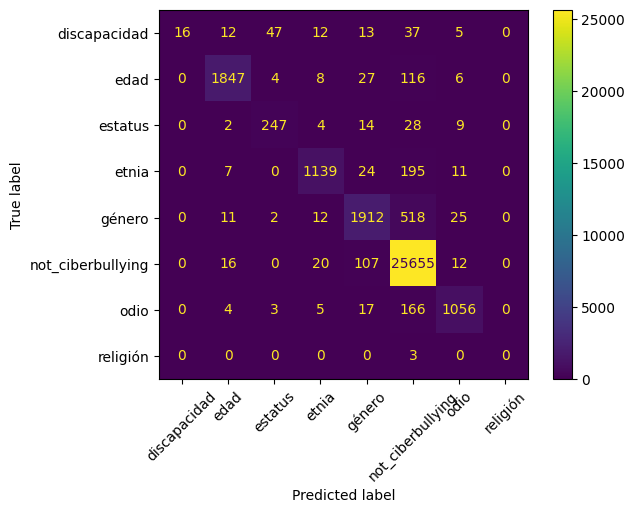

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred_classes)
ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(xticks_rotation=45)

Epoch 1/5
2086/2086 ━━━━━━━━━━━━━━━━━━━━ 45s 22ms/step - accuracy: 0.9742 - loss: 0.1031 - val_accuracy: 0.9596 - val_loss: 0.1972
Epoch 2/5
2086/2086 ━━━━━━━━━━━━━━━━━━━━ 44s 21ms/step - accuracy: 0.9825 - loss: 0.0767 - val_accuracy: 0.9631 - val_loss: 0.1931
Epoch 3/5
2086/2086 ━━━━━━━━━━━━━━━━━━━━ 43s 21ms/step - accuracy: 0.9870 - loss: 0.0570 - val_accuracy: 0.9660 - val_loss: 0.1984
Epoch 4/5
2086/2086 ━━━━━━━━━━━━━━━━━━━━ 43s 21ms/step - accuracy: 0.9896 - loss: 0.0446 - val_accuracy: 0.9684 - val_loss: 0.1992
Epoch 5/5
2086/2086 ━━━━━━━━━━━━━━━━━━━━ 43s 21ms/step - accuracy: 0.9929 - loss: 0.0323 - val_accuracy: 0.9684 - val_loss: 0.2073


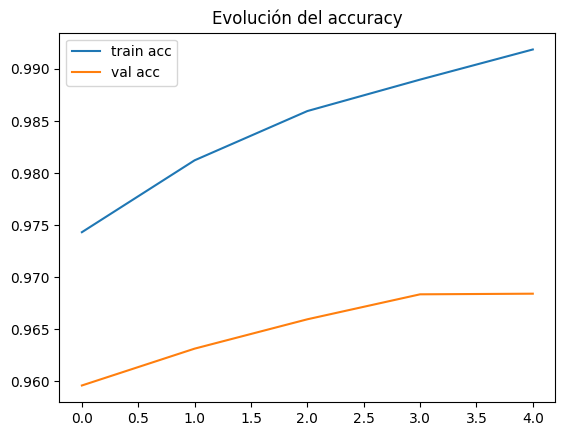

In [ ]:
import matplotlib.pyplot as plt

history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=5, batch_size=64)

plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.title('Evolución del accuracy')
plt.show()